In [1]:
import pandas as pd
from tqdm.notebook import tqdm
from pprint import pprint
import tokenizer
import importlib
importlib.reload(tokenizer)
import json
import torch
import torch.nn as nn
import pandas as pd
import rnn
from torch.utils.tensorboard import SummaryWriter

In [2]:
df_test = pd.read_parquet('data/test_wiki_cleaned_cutted.pq')

In [3]:
with open("artifacts/character_tokenizer.json", "r", encoding="utf-8") as f:
    dict_json = json.load(f)

In [4]:
tok = tokenizer.Tokenizer.from_dict(dict_json)

In [5]:
class WikipediaDataset(torch.utils.data.Dataset):
    def __init__(self, texts: list, tokenizer: tokenizer.Tokenizer, max_len: int):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, i):
        tokens = self.tokenizer.encode(self.texts[i])
        tokens = torch.tensor(tokens, dtype=torch.long)
        tokens = tokens[:self.max_len]

        if(len(tokens) < self.max_len):
            n_pad_fill = self.max_len - len(tokens)
            pad_fill = torch.tensor([tok.pad_token_id]*n_pad_fill, dtype=torch.long)
            tokens = torch.concat([tokens, pad_fill])

        input_tokens = tokens[:-1]
        target_tokens = tokens[1:]

        return input_tokens, target_tokens


In [6]:
dataset_test = WikipediaDataset(
    df_test.text_cut.values.tolist(),
    tok,
    max_len=200
)

In [7]:
config_test = {
    'batch_size': 512,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

step_info = {'test_accum_steps': 0, 'test_loss_sum':0}

In [8]:
torch.cuda.is_available() 

True

In [17]:
model_names = [f'train_v{v}' for v in range(1,8)]
modelos = {}
configs = {}
for model_name in model_names:
    with open(f"models/{model_name}/config.json", "r", encoding="utf-8") as f:
        config_train: dict = json.load(f)
    
    model = rnn.MyModel(
        tok.vocab_size, 
        config_train['embed_size'], 
        config_train['hidden_size'], 
        config_train['num_layers']
        ).to(config_train['device'])
    model.load_state_dict(torch.load(f"models/{model_name}/model.pt"))
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    config_train['parameters'] = trainable_params
    config_train.pop('device')
    config_train.pop('name_exp')
    config_train.pop('earlying_stop_criteria')
    modelos[model_name] = model
    configs[model_name] = config_train

# Configurações de treino de cada um dos modelos

In [185]:
pd.DataFrame(configs).T

,batch_size,eval_batch_size,accum_steps,eval_acum_steps,epochs,eval_step,log_steps,embed_size,hidden_size,num_layers,learning_rate,desc,parameters
train_v1,64,64,1,1,100,1000,250,256,512,4,0.0001,Tamanho ok,8249055
train_v2,64,64,1,1,100,1000,250,256,1024,6,0.0001,Avaliando se aumentando o tamanho de layers aj...,47848671
train_v3,64,64,1,1,100,1000,250,128,512,2,0.00005,"Embedding size menor, com uma rede menor para ...",3723103
train_v4,64,64,1,1,100,1000,250,256,512,4,0.0001,Adicionando clip norm para avaliar eficiência,8249055
train_v5,32,64,1,1,100,1000,250,128,512,2,0.0001,Aumentando learning rate da versão v3 e clippa...,3723103
train_v6,16,64,1,1,100,1000,250,128,512,2,0.0001,Somente reduzindo da v5 o batch_size.,3723103
train_v7,16,64,1,1,100,1000,250,128,256,2,0.0001,Reduzindo hidden state em relação ao v6,1106015


# Loss de Validação e Treinamento

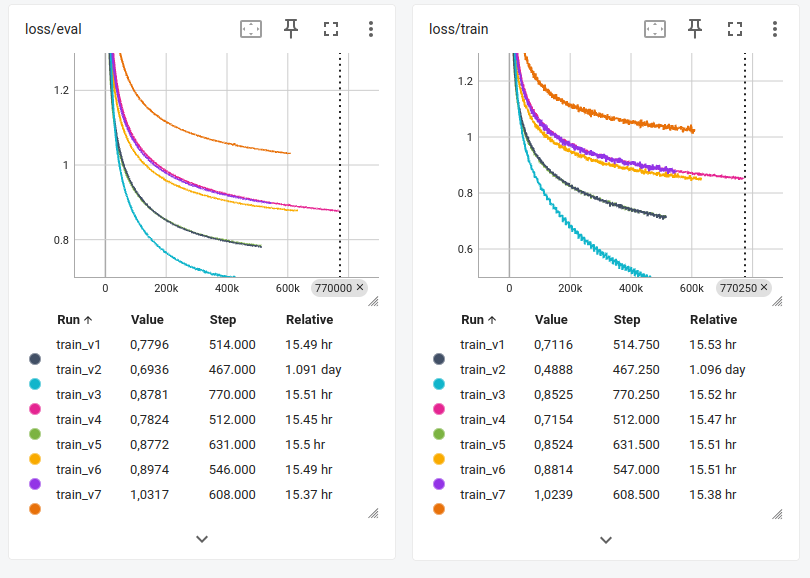

In [186]:
dataloader_test = torch.utils.data.DataLoader(
        dataset=dataset_test, 
        batch_size=config_test['batch_size'],
        shuffle=True
)

In [190]:
def test_step(config, step_info, model, dataloader, vocab_size, tok: tokenizer.Tokenizer):
    model.eval()
    phrases_pred, tokens_pred_total = [], []
    phrases_input, tokens_input_total = [], []
    for batch in tqdm(dataloader, total=len(dataloader), desc='Testing'):
        input_tokens, output_tokens = batch
        input_tokens: torch.Tensor = input_tokens.to(config['device'])
        output_tokens = output_tokens.to(config['device'])

        states = None
        predict_tokens, states = model(input_tokens, states) #Batch, Seq Len, Vocab Size
        pred_tokens = predict_tokens

        predict_tokens = predict_tokens.view(-1, vocab_size) # Batch*Seq Len, Vocab Size
        output_tokens = output_tokens.view(-1)

        loss = nn.functional.cross_entropy(predict_tokens, output_tokens, ignore_index=0)

        step_info['test_accum_steps'] += 1
        step_info['test_loss_sum'] += loss.item()

        if(states):
            states = (states[0].detach(), states[1].detach())

        pred_tokens = torch.argmax(pred_tokens, dim=-1)
        for i in range(len(pred_tokens)):
            p_tokens = pred_tokens[i].tolist()
            p2_tokens = input_tokens[i].tolist()
            p = tok.decode(p_tokens)
            p2 = tok.decode(p2_tokens)
            phrases_pred.append(p)
            tokens_pred_total.append(p_tokens)
            phrases_input.append(p2)
            tokens_input_total.append(p2_tokens)


    avg_loss = step_info['test_loss_sum'] / step_info['test_accum_steps']
    
    step_info['test_loss_sum'] = 0
    step_info['test_accum_steps'] = 0

    return avg_loss, phrases_pred, phrases_input, tokens_pred_total, tokens_input_total

In [191]:
df_results = pd.DataFrame()
for model_name, model in modelos.items():
    loss, phrases_pred, phrases_input, tokens_pred_total, tokens_input_total = test_step(config_test, step_info, modelos[model_name], dataloader_test, tok.vocab_size, tok)
    df_results = pd.concat([df_results,pd.DataFrame({
        'modelo': [model_name]*len(phrases_input), 
        'frase_original': phrases_input, 
        'frase_preditada': phrases_pred,
        'tokens_originais': tokens_input_total,
        'tokens_preditados': tokens_pred_total,
        'loss': [loss]*len(phrases_input)
        })])

Testing:   0%|          | 0/298 [00:00<?, ?it/s]

Testing:   0%|          | 0/298 [00:00<?, ?it/s]

Testing:   0%|          | 0/298 [00:00<?, ?it/s]

Testing:   0%|          | 0/298 [00:00<?, ?it/s]

Testing:   0%|          | 0/298 [00:00<?, ?it/s]

Testing:   0%|          | 0/298 [00:00<?, ?it/s]

Testing:   0%|          | 0/298 [00:00<?, ?it/s]

In [193]:
df_results.to_parquet('inf/df_results.pq', index=False)

In [10]:
df_results = pd.read_parquet('inf/df_results.pq')

In [28]:
import numpy as np
def count_eos(tokens: list, tokenizer: tokenizer.Tokenizer):
    return np.count_nonzero(tokens == 2)

In [31]:
df_results['count_eos'] = df_results['tokens_preditados'].apply(lambda x: count_eos(x, tok))

In [32]:
df_results.head(20)

,modelo,frase_original,frase_preditada,tokens_originais,tokens_preditados,loss,count_eos
0,train_v1,"<bos>Marisol Nichols Chicago, 2 de novembro de...","Aariaal éicoola 1aacago, 24de aovembro de 1970...","[1, 35, 49, 66, 57, 67, 63, 60, 4, 36, 57, 51,...","[23, 49, 66, 57, 49, 49, 60, 4, 117, 57, 51, 6...",0.781031,9
1,train_v1,<bos>O MTV Video Music Brasil de 2011 também c...,A CoV Video Music Arasil 2e 2017 fambém conhec...,"[1, 37, 4, 35, 42, 44, 4, 44, 57, 52, 53, 63, ...","[23, 4, 25, 63, 44, 4, 44, 57, 52, 53, 63, 4, ...",0.781031,17
2,train_v1,"<bos>Jeffrey Hoogland Nijverdal, 16 de março d...",Aoafrey Haukeend Cocoassele 11 de jarço de 198...,"[1, 32, 53, 54, 54, 66, 53, 73, 4, 30, 63, 63,...","[23, 63, 49, 54, 66, 53, 73, 4, 30, 49, 69, 59...",0.781031,8
3,train_v1,<bos>O Rolex Paris Masters é um torneio de tên...,A Ceylx Porks éanters é um tirneio de tênis da...,"[1, 37, 4, 40, 63, 60, 53, 72, 4, 38, 49, 66, ...","[23, 4, 25, 53, 73, 60, 72, 4, 38, 63, 66, 59,...",0.781031,18
4,train_v1,<bos>Museu da Imagem e Som de Alagoas MISA é u...,Aaseu de Igagem e doceéo Slegoas éeSTTf um mus...,"[1, 35, 69, 67, 53, 69, 4, 52, 49, 4, 31, 61, ...","[23, 49, 67, 53, 69, 4, 52, 53, 4, 31, 55, 49,...",0.781031,22
5,train_v1,<bos>A Seletiva Maranhense de 2016 do Campeona...,A peleçiva dutanhense de F017 fe Bampeonato Pi...,"[1, 23, 4, 41, 53, 60, 53, 68, 57, 70, 49, 4, ...","[23, 4, 64, 53, 60, 53, 115, 57, 70, 49, 4, 52...",0.781031,11
6,train_v1,<bos>Os seus níveis caem após um processo hemo...,A peus poveis dormbdtrs am ceocesso derorític...,"[1, 37, 67, 4, 67, 53, 69, 67, 4, 62, 121, 70,...","[23, 4, 4, 64, 53, 69, 67, 4, 64, 63, 70, 53, ...",0.781031,42
7,train_v1,<bos>O HMS Raleigh foi um cruzador pesado oper...,A CoS Resligh foi um couzador desado operado p...,"[1, 37, 4, 30, 35, 41, 4, 40, 49, 60, 53, 57, ...","[23, 4, 25, 63, 41, 4, 40, 53, 67, 60, 57, 55,...",0.781031,2
8,train_v1,<bos>As Paquitas foram um grupo brasileiro de ...,A eoruitas doram umagrupo drasileiro de btsan...,"[1, 23, 67, 4, 38, 49, 65, 69, 57, 68, 49, 67,...","[23, 4, 4, 53, 63, 66, 69, 57, 68, 49, 67, 4, ...",0.781031,1
9,train_v1,<bos>O Lorde-Prefeito de Londres inglês: Lord ...,A Cacde Arefeito de Pindres englês: Lani Lanor...,"[1, 37, 4, 34, 63, 66, 52, 53, 8, 38, 66, 53, ...","[23, 4, 25, 49, 51, 52, 53, 4, 23, 66, 53, 54,...",0.781031,1


In [38]:
df_results.groupby('modelo')['loss'].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
modelo,,,,,,,,
train_v2,152477.0,0.692304,0.000000e+00,0.692304,0.692304,0.692304,0.692304,0.692304
train_v1,152477.0,0.781031,0.000000e+00,0.781031,0.781031,0.781031,0.781031,0.781031
train_v4,152477.0,0.782917,2.220453e-16,0.782917,0.782917,0.782917,0.782917,0.782917
train_v5,152477.0,0.876082,2.220453e-16,0.876082,0.876082,0.876082,0.876082,0.876082
train_v3,152477.0,0.876373,0.000000e+00,0.876373,0.876373,0.876373,0.876373,0.876373
train_v6,152477.0,0.897329,2.220453e-16,0.897329,0.897329,0.897329,0.897329,0.897329
train_v7,152477.0,1.031448,2.220453e-16,1.031448,1.031448,1.031448,1.031448,1.031448


In [39]:
df_results.groupby('modelo')['count_eos'].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
modelo,,,,,,,,
train_v7,152477.0,5.037527,2.547020,0.0,3.0,5.0,7.0,18.0
train_v3,152477.0,6.994825,6.923239,0.0,2.0,5.0,10.0,46.0
train_v6,152477.0,9.733002,8.663042,0.0,3.0,7.0,14.0,48.0
train_v2,152477.0,10.337717,8.567057,0.0,3.0,8.0,15.0,48.0
train_v1,152477.0,12.585092,8.748842,0.0,5.0,11.0,18.0,49.0
train_v4,152477.0,13.282764,9.239504,0.0,6.0,12.0,19.0,47.0
train_v5,152477.0,14.915771,8.616175,0.0,8.0,15.0,21.0,48.0


In [40]:
df_results[df_results.modelo == 'train_v2'].head(20)

,modelo,frase_original,frase_preditada,tokens_originais,tokens_preditados,loss,count_eos
152477,train_v2,<bos>Monte Baldo é uma montanha dos Alpes nos ...,Aante Caldu é uma fontanha no Alpes Jos Aié-A...,"[1, 35, 63, 62, 68, 53, 4, 24, 49, 60, 52, 63,...","[23, 49, 62, 68, 53, 4, 25, 49, 60, 52, 69, 4,...",0.692304,6
152478,train_v2,<bos>Danielle Barboza Duarte Silva Rio de Jane...,"Aeniel e Carbosa Suarte Silva Cio de Janeiro, ...","[1, 26, 49, 62, 57, 53, 60, 60, 53, 4, 24, 49,...","[23, 53, 62, 57, 53, 60, 4, 53, 4, 25, 49, 66,...",0.692304,25
152479,train_v2,<bos>Freestyle ou estilo livre é uma categoria...,Aoaddtyle Br tstilo detre é um rategoria de c...,"[1, 28, 66, 53, 53, 67, 68, 73, 60, 53, 4, 63,...","[23, 63, 49, 52, 52, 68, 73, 60, 53, 4, 24, 66...",0.692304,7
152480,train_v2,"<bos>Sir Ingram de Umfraville a c Em 1284, el...","Aal Jsêram Se Bnaeitirle,nnV El 1504, ele se ...","[1, 41, 57, 66, 4, 31, 62, 55, 66, 49, 61, 4, ...","[23, 49, 60, 4, 32, 67, 118, 66, 49, 61, 4, 41...",0.692304,26
152481,train_v2,"<bos>2 Partidas e gols totais pelos clubes, at...","A Partidas e gols totais pelos clubes, atualiz...","[1, 12, 4, 38, 49, 66, 68, 57, 52, 49, 67, 4, ...","[23, 4, 38, 49, 66, 68, 57, 52, 49, 67, 4, 53,...",0.692304,20
152482,train_v2,<bos>As filmagens ocorreram de agosto de 2005 ...,A colmagens ocorreram ee 1costo de 2001 a 1an...,"[1, 23, 67, 4, 54, 57, 60, 61, 49, 55, 53, 62,...","[23, 4, 4, 51, 63, 60, 61, 49, 55, 53, 62, 67,...",0.692304,18
152483,train_v2,<bos>The King of Fighters 2001 é um jogo de lu...,Ahe Bing of Fighters 2001 é um jogo de luta pr...,"[1, 42, 56, 53, 4, 33, 57, 62, 55, 4, 63, 54, ...","[23, 56, 53, 4, 24, 57, 62, 55, 4, 63, 54, 4, ...",0.692304,11
152484,train_v2,<bos>Hamilton é uma cidade em South Lanarkshir...,"Aaralton C uma cidade l Utcth Yana,kshire, na...","[1, 30, 49, 61, 57, 60, 68, 63, 62, 4, 117, 4,...","[23, 49, 66, 49, 60, 68, 63, 62, 4, 25, 4, 69,...",0.692304,21
152485,train_v2,<bos>Lambari é um município do estado de Minas...,Aa beri é um município da estado de Sanas Gera...,"[1, 34, 49, 61, 50, 49, 66, 57, 4, 117, 4, 69,...","[23, 49, 4, 50, 53, 66, 57, 4, 117, 4, 69, 61,...",0.692304,29
152486,train_v2,<bos>Pelas suas contribuições para o desenvolv...,Aaro gsuas contribuições para o eesenvolviment...,"[1, 38, 53, 60, 49, 67, 4, 67, 69, 49, 67, 4, ...","[23, 49, 66, 63, 4, 55, 67, 69, 49, 67, 4, 51,...",0.692304,21


In [14]:
initial_texts = [
    "São Paulo é um município",
    "O Brasil é um país",
    "A capital da França é",
    "A água é ",
    "O Sol é",
    "A Terra gira em torno",
    "A fotossíntese é",
    "Um vírus é",
    "A energia elétrica é",
    "A linguagem humana é",
    "A democracia é",
    "O sistema solar é",
    "A Lua",
    "A Revolução Industrial",
    "A inteligência artificial é"
    ]


In [15]:
def predicting(initial_text: str, model, max_len, tok: tokenizer.Tokenizer, eos_penalty_base: float, temperature: float, k=1):
    model.eval()

    enc_text_atual = tok.encode(initial_text)[:-1]
    enc_text_atual = torch.tensor(enc_text_atual, dtype=torch.long)
    enc_text_atual = enc_text_atual.to('cuda')
    states = None

    for i in range(max_len):
        logits, states = model(enc_text_atual, states)
        logits = logits[-1, :]

        # penaliza EOS
        logits[tok.eos_token_id] *= eos_penalty_base + (i / max_len)

        # temperatura (ANTES do softmax)
        logits = logits / temperature

        probs = torch.softmax(logits, dim=-1)

        # top-k
        topk_probs, topk_indices = torch.topk(probs, k=k)

        # renormaliza
        topk_probs = topk_probs / topk_probs.sum()

        # sample correto
        next_token = torch.multinomial(topk_probs, 1)
        next_token = topk_indices[next_token]

        if next_token.item() == tok.eos_token_id:
            break

        enc_text_atual = torch.cat([
            enc_text_atual,
            next_token
        ])

    return tok.decode(enc_text_atual.tolist()[1:])


In [42]:
testes = {'temperature': [1, 0.8, 0.7, 0.5], 'k': [1, 2, 3, 4]}


In [49]:
results = []
testes = {'temperature': [1, 0.8, 0.7, 0.5], 'k': [1, 2, 3, 4]}

for model_name, model in modelos.items():
    for i in range(len(testes[list(testes.keys())[0]])):
        print(f"Rodando modelo: {model_name}")
        for initial_text in initial_texts:
            output = predicting(
                initial_text=initial_text,
                model=model,
                max_len=200,
                tok=tok,
                eos_penalty_base=0.2,
                temperature=testes['temperature'][i],
                k=testes['k'][i]
            )

            results.append({
                "modelo": model_name,
                "pergunta": initial_text,
                "resposta_gerada": output,
                'temperatura': testes['temperature'][i],
                'k':testes['k'][i],
            })

df = pd.DataFrame(results)


Rodando modelo: train_v1
Rodando modelo: train_v1
Rodando modelo: train_v1
Rodando modelo: train_v1
Rodando modelo: train_v2
Rodando modelo: train_v2
Rodando modelo: train_v2
Rodando modelo: train_v2
Rodando modelo: train_v3
Rodando modelo: train_v3
Rodando modelo: train_v3
Rodando modelo: train_v3
Rodando modelo: train_v4
Rodando modelo: train_v4
Rodando modelo: train_v4
Rodando modelo: train_v4
Rodando modelo: train_v5
Rodando modelo: train_v5
Rodando modelo: train_v5
Rodando modelo: train_v5
Rodando modelo: train_v6
Rodando modelo: train_v6
Rodando modelo: train_v6
Rodando modelo: train_v6
Rodando modelo: train_v7
Rodando modelo: train_v7
Rodando modelo: train_v7
Rodando modelo: train_v7


In [62]:
df_atual_avaliar = df[
    (df['pergunta'] == initial_texts[0])
    & (df['temperatura'] == 1)
    ]
for i_, d in df_atual_avaliar.iterrows():
    print(f"{d['modelo']}: {d['resposta_gerada']}")

train_v1: São Paulo é um município brasileiro do estado do Paraná 200 habitantes pelo IBGE Inolgrávia S/A Comunidade de Portugal: C
train_v2: São Paulo é um município brasileiro do estado de Minas Gerais 999 km² e 1367 habitantes por km 2, da cidade de São Paulo
train_v3: São Paulo é um município brasileiro situado no estado de Mato Grosso do Sul  Localiza-se a uma latitude sul e a uma longitude oeste, estando a uma altitude de 380 metros
train_v4: São Paulo é um município brasileiro do estado de São Paulo  Localiza-se a uma latitude sul e a 30 longitude 50 364 oeste e 12 000 habitantes
train_v5: São Paulo é um município brasileiro do estado de Minas Gerais  Possui área de 107,79 km² com população de 119 735 habitantes em 2021
train_v6: São Paulo é um município brasileiro do estado de São Paulo  Pelo Censo 2010 IBGE a população total do distrito era de 115 487 habitantes
train_v7: São Paulo é um município da Espanha na comarca de Barcelona e Coronel Center na direção da constelação de 

In [59]:
df_atual_avaliar = df[
    (df['pergunta'] == initial_texts[-1])
    & (df['temperatura'] == 1)
    ]
for i_, d in df_atual_avaliar.iterrows():
    print(f"{d['modelo']}: {d['resposta_gerada']}")

train_v1: A inteligência artificial é um conjunto de processos iniciais de desenvolvimento integrado IBC 000 objetos em 1991 G
train_v2: A inteligência artificial é um processo estocástico contra o espaço vetorial ou arte martinstritite valiosa em sua forma em 1990
train_v3: A inteligência artificial é uma das propriedades do metal alternativo da NASA  A empresa foi criada em 1994 por John F
train_v4: A inteligência artificial é uma das ciências da atividade econômica do país em 1999: 1999 e 2009 e 2011-2022
train_v5: A inteligência artificial é uma sequência de carbono 3 e 100 g/c
train_v6: A inteligência artificial é um componente de um composto orgânico de fórmula química C 6 H 2 O 2  N
train_v7: A inteligência artificial é uma das mais importantes do mundo e a propriedade de conservação de conteúdos de conteúdo de computadores e computadores de computador
